In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
df=pd.read_csv('/Users/ashish/Desktop/House-Price-Prediction/final_housing.csv')

In [25]:
df.head(10)

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,renovated
0,0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,0
1,1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1
2,2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,0
3,3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,0
4,4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,0
5,5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,0
6,6,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,0
7,7,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,0
8,8,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,0
9,9,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,0


In [4]:
X=df.loc[:,"sqft_living"]
y=df.loc[:,"price"]

/Users/ashish/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


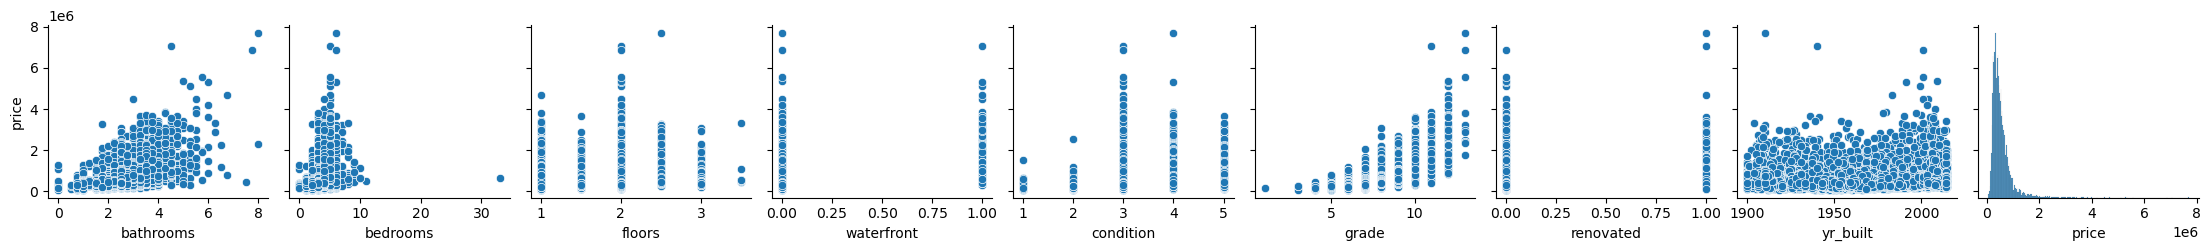

In [5]:
variables=["bathrooms","bedrooms","floors","waterfront","condition","grade","renovated","yr_built","price"]
dataframe=df.loc[:,variables]
sns.pairplot(dataframe,y_vars="price",diag_kind='hist')
plt.show()

In [6]:
print(df['grade'].value_counts())

grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64


In [7]:
values_1=df['price'].groupby(df['grade']).mean()

In [8]:
values_1

grade
1     1.420000e+05
3     2.056667e+05
4     2.143810e+05
5     2.485240e+05
6     3.019196e+05
7     4.025903e+05
8     5.428528e+05
9     7.735132e+05
10    1.071771e+06
11    1.496842e+06
12    2.191222e+06
13    3.709615e+06
Name: price, dtype: float64

[ 1  2  3  4  5  6  7  8  9 10 11 12 13]
[ 1  3  4  5  6  7  8  9 10 11 12 13]


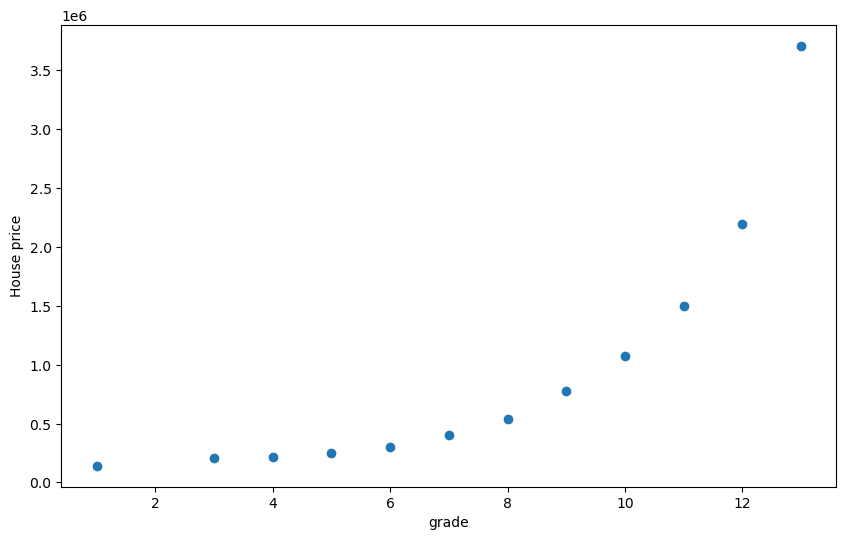

In [13]:
#the following chart clearly shows the increase in grading leads to increase price(explonentially), there's no grade 2 house
X3=np.arange(1,14)
print(X3)
X3=np.delete(X3,1)
print(X3)
y2=values_1.to_numpy()
plt.figure(figsize=(10,6))
plt.scatter(X3,y2)
plt.xlabel("grade")
plt.ylabel("House price")
plt.show()

In [15]:
print(df['condition'].value_counts())
values_2=df['price'].groupby(df['condition']).mean()
print(values_2)

condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64
condition
1    334431.666667
2    327287.145349
3    542012.578148
4    521200.390033
5    612418.089359
Name: price, dtype: float64


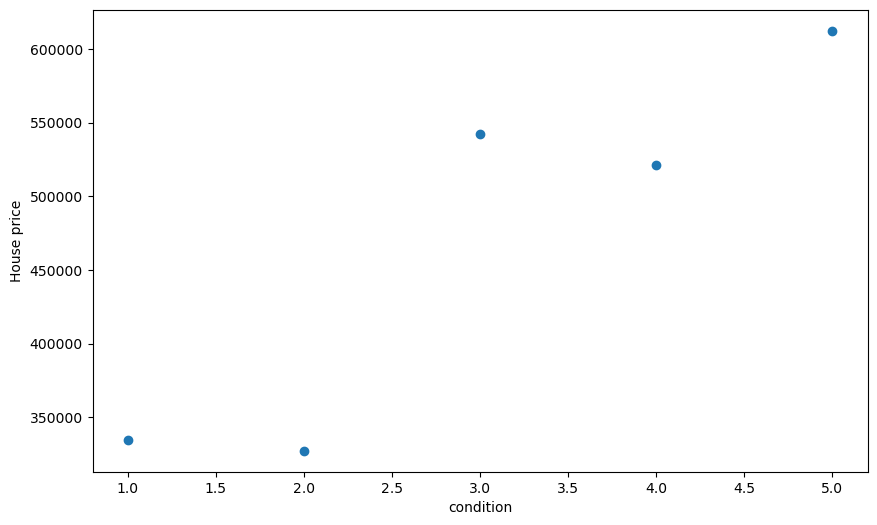

In [16]:
x3=np.arange(1,6)
plt.figure(figsize=(10,6))
plt.scatter(x3,values_2)
plt.xlabel("condition")
plt.ylabel("House price")
plt.show()

In [15]:
#the following shows that there's 70 unique pincode in the dataset

In [18]:
df['zipcode'].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

In [19]:
df['zipcode'].unique().min()

98001

In [20]:
df['zipcode'].unique().max()

98199

In [21]:
#now lets find the correlation between pincode and housing price, seeing the influence on the prices we should use zipcodes as a categorical variable using label encoding

In [22]:
prices_zipcode=df['price'].groupby(df['zipcode']).mean().sort_index()

In [23]:
prices_zipcode

zipcode
98001    2.808047e+05
98002    2.342840e+05
98003    2.941113e+05
98004    1.355927e+06
98005    8.101649e+05
             ...     
98177    6.761854e+05
98178    3.106128e+05
98188    2.890783e+05
98198    3.028789e+05
98199    7.918208e+05
Name: price, Length: 70, dtype: float64

In [24]:
zipCodes=sorted(df['zipcode'].unique())

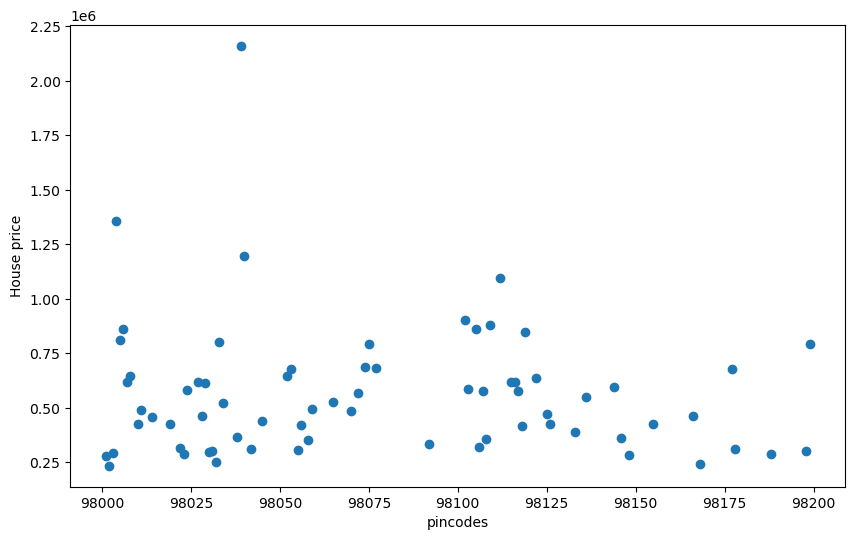

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(zipCodes,prices_zipcode)
plt.xlabel("pincodes")
plt.ylabel("House price")
plt.show()

In [26]:
yearsBuilt=sorted(df['yr_built'].unique())

In [27]:
price_yearbuilt=df['price'].groupby(df['yr_built']).mean()

In [28]:
price_yearbuilt

yr_built
1900    581387.206897
1901    556935.931034
1902    673007.407407
1903    480958.195652
1904    583756.644444
            ...      
2011    544522.000000
2012    527447.335294
2013    678545.452736
2014    683681.754919
2015    759785.157895
Name: price, Length: 116, dtype: float64

In [29]:
#lets conclude if there's any relation between the no. of houses in the area(same pincode) & price i.e. does dense areas lead any changes in the pincode

In [30]:
zip_code_count=df['price'].groupby(df['zipcode']).count().sort_index()

In [31]:
zip_code_count

zipcode
98001    362
98002    199
98003    280
98004    317
98005    168
        ... 
98177    255
98178    262
98188    136
98198    280
98199    317
Name: price, Length: 70, dtype: int64

In [32]:
zip_code_count.min()

50

In [33]:
prices_zipcode

zipcode
98001    2.808047e+05
98002    2.342840e+05
98003    2.941113e+05
98004    1.355927e+06
98005    8.101649e+05
             ...     
98177    6.761854e+05
98178    3.106128e+05
98188    2.890783e+05
98198    3.028789e+05
98199    7.918208e+05
Name: price, Length: 70, dtype: float64

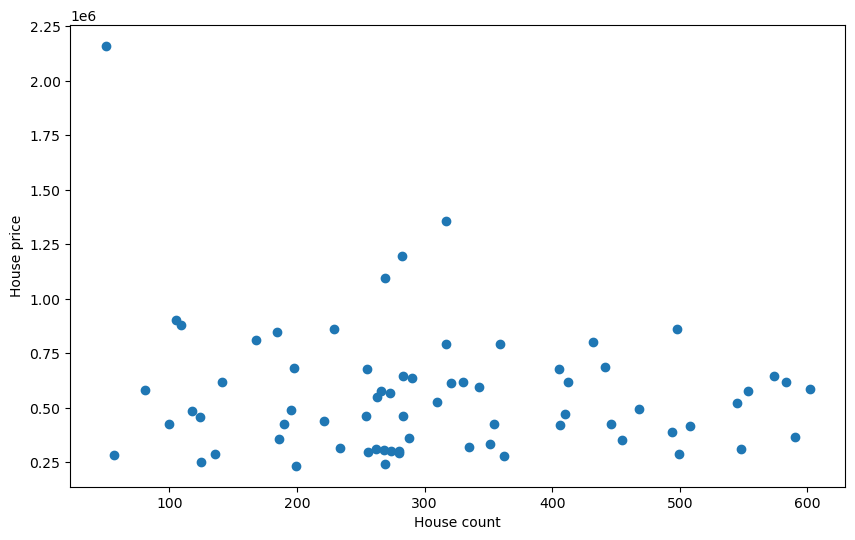

In [36]:
plt.figure(figsize=(10,6))
plt.scatter(zip_code_count,prices_zipcode)
plt.xlabel("House count")
plt.ylabel("House price")
plt.show()

In [35]:
#the graph depicts a gated community in the dataset with bare min-50 houses with the most inflated prices

In [5]:
df.head()

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,renovated
0,0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,0
1,1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1
2,2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,0
3,3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,0
4,4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,0


In [6]:
for cols in df.columns:
    print(cols)

Unnamed: 0
price
bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
grade
sqft_above
sqft_basement
yr_built
zipcode
lat
long
renovated


In [7]:
df.drop(columns=['Unnamed: 0'],inplace=True)

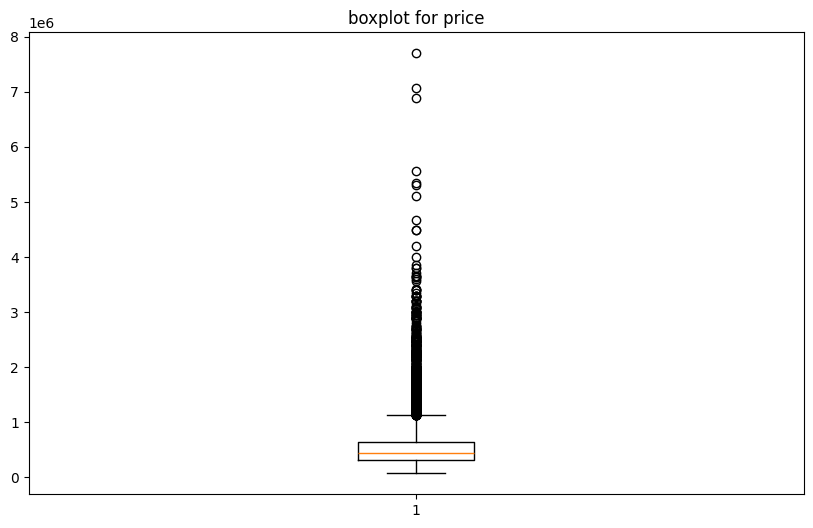

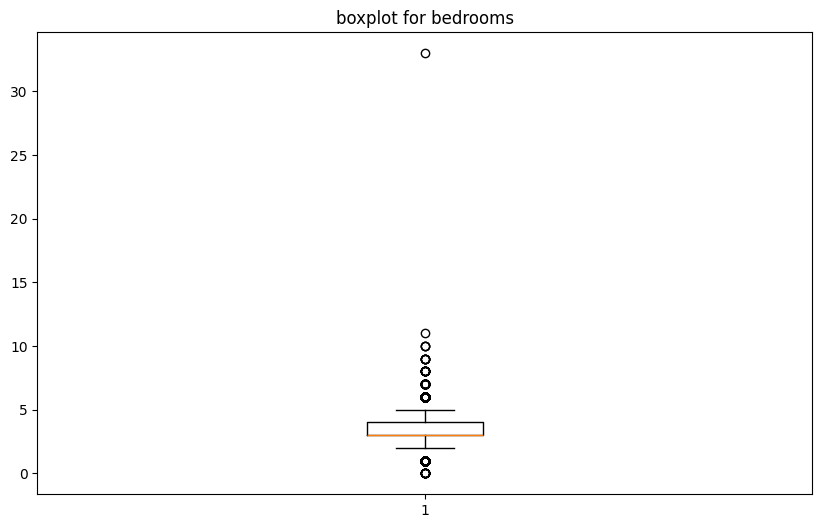

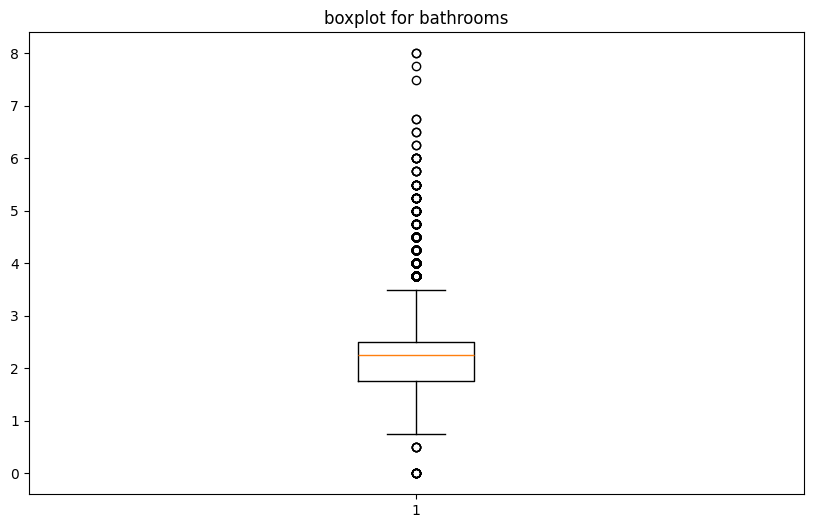

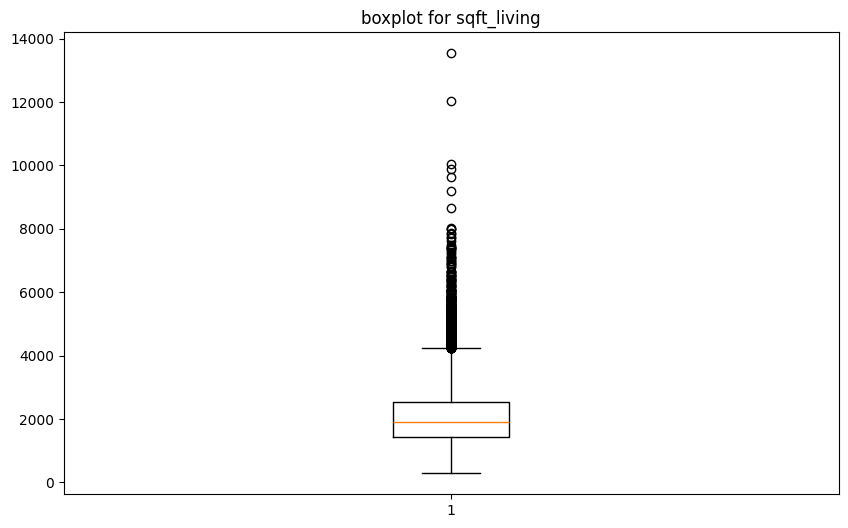

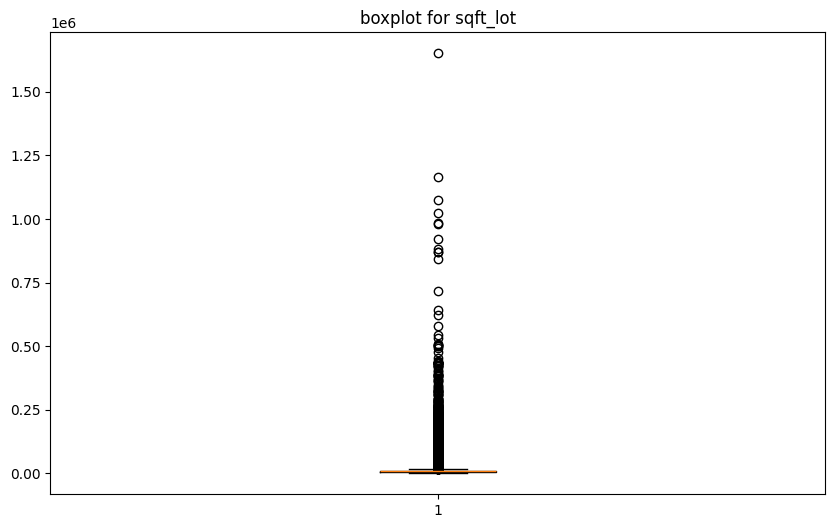

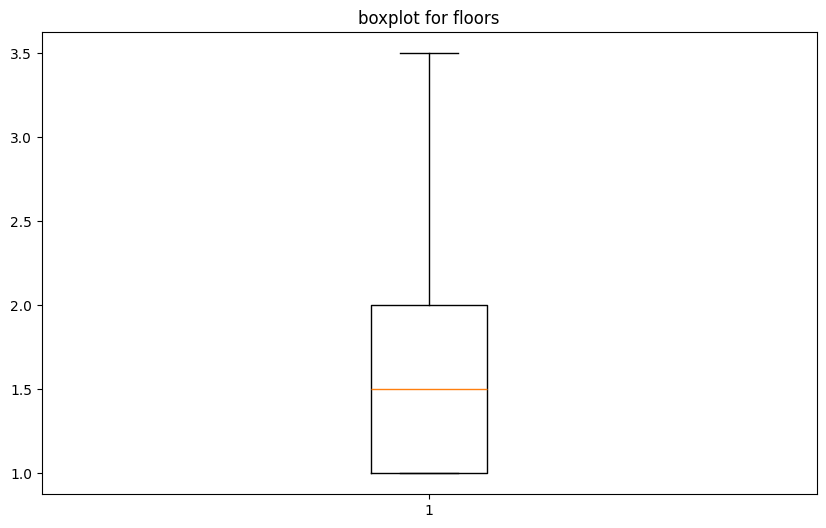

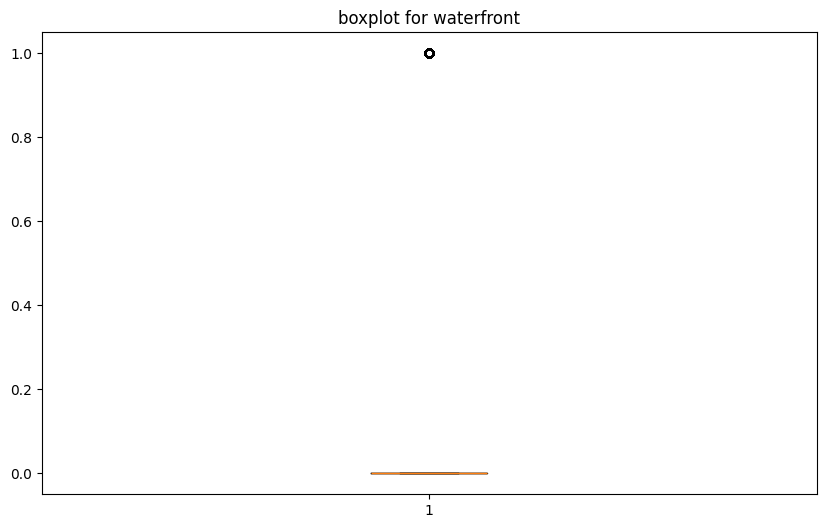

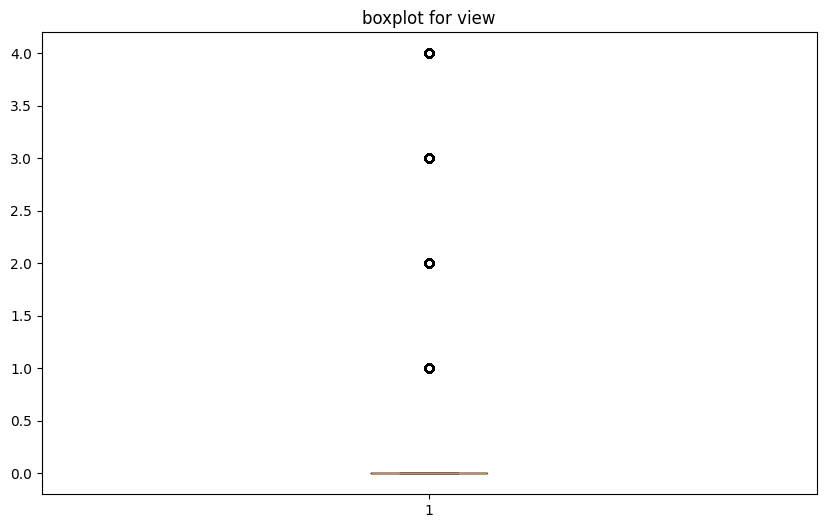

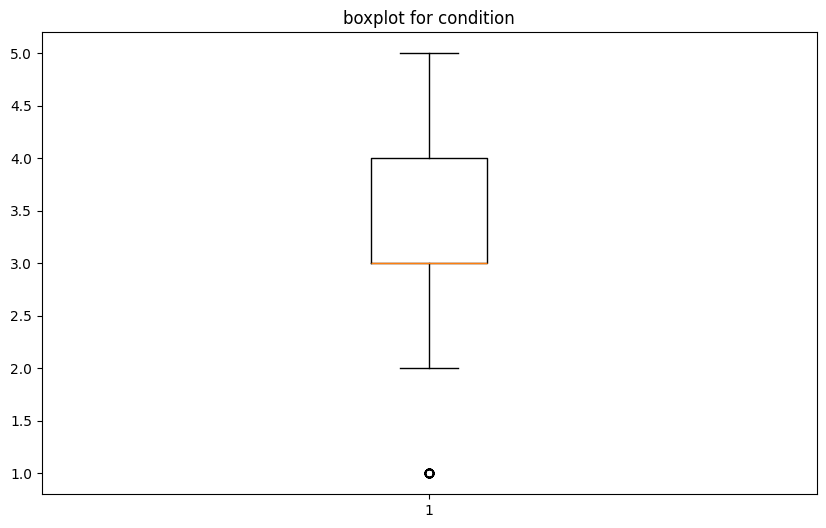

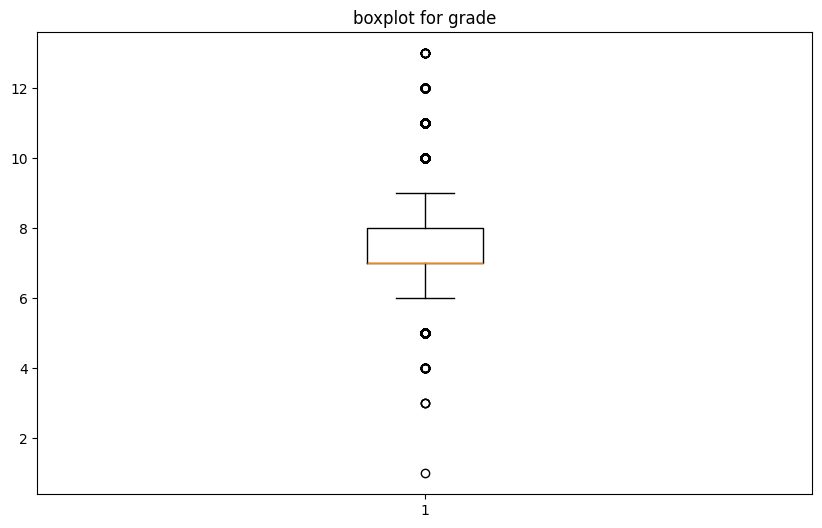

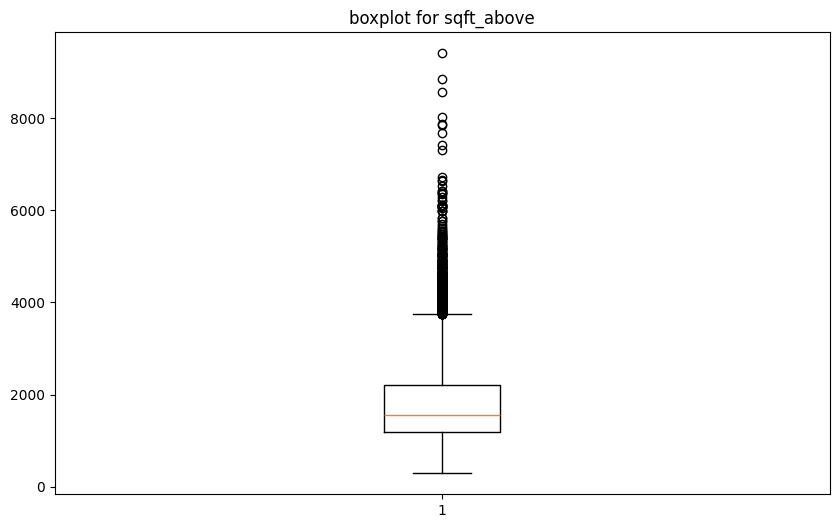

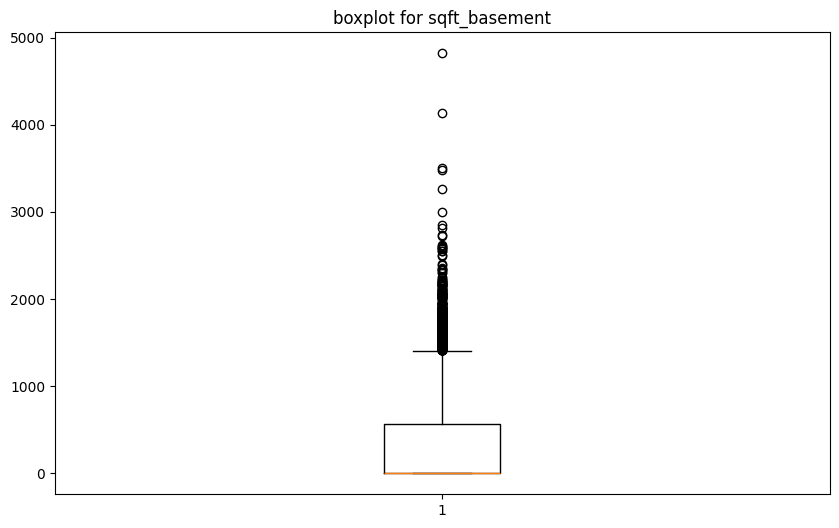

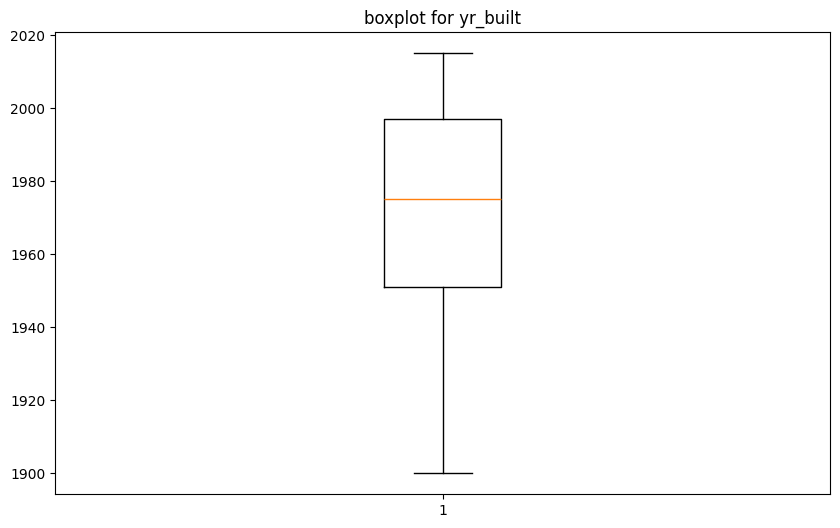

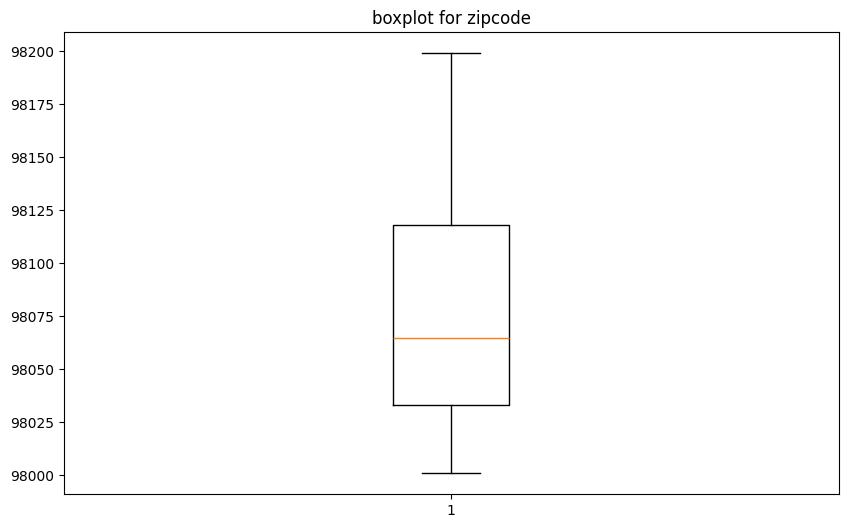

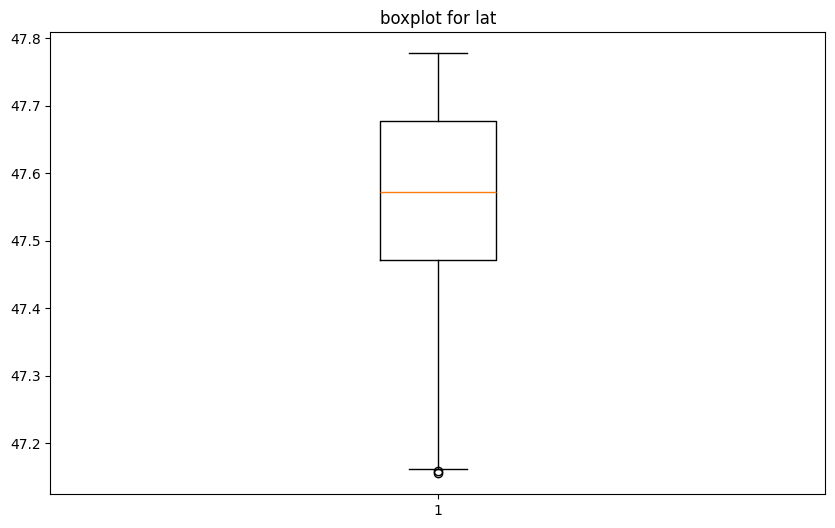

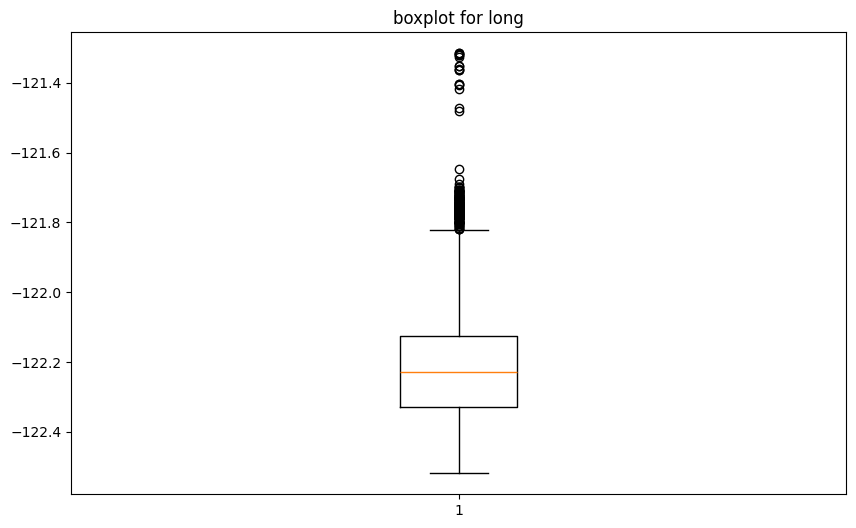

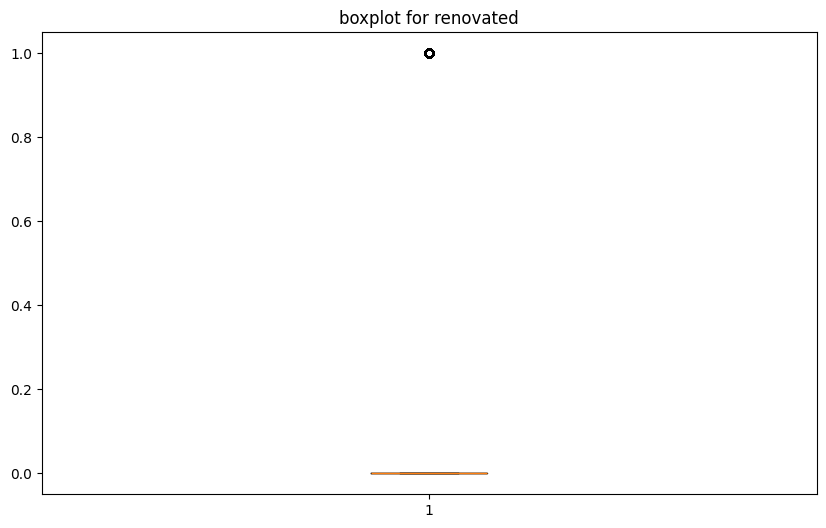

In [10]:
for cols in df.columns:
    plt.figure(figsize=(10,6))
    plt.boxplot(df[cols])
    plt.title(f"boxplot for {cols}")
    plt.show()
    

In [16]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

price: 1146 outliers
bedrooms: 546 outliers
bathrooms: 571 outliers
sqft_living: 572 outliers
sqft_lot: 2425 outliers
floors: 0 outliers
waterfront: 163 outliers
view: 2124 outliers
condition: 30 outliers
grade: 1911 outliers
sqft_above: 611 outliers
sqft_basement: 496 outliers
yr_built: 0 outliers
zipcode: 0 outliers
lat: 2 outliers
long: 256 outliers
renovated: 914 outliers


In [19]:
for col in df.columns:
    print(col,":",df[col].dtype)

price : float64
bedrooms : int64
bathrooms : float64
sqft_living : int64
sqft_lot : int64
floors : float64
waterfront : int64
view : int64
condition : int64
grade : int64
sqft_above : int64
sqft_basement : int64
yr_built : int64
zipcode : int64
lat : float64
long : float64
renovated : int64
